<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-311/blob/main/CPE311_HOA10.1_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*CPE311 Computational Thinking with Python*

Submitted by: Escalada, Lhei Matthew <br>
Performed on: 09/04/2026 <br>
Submitted on: 10/04/2026 <br>
Submitted to: Engr. Neal Barton James Matira <br>

In [ ]:
import pandas as pd
import numpy as np

# --- 1. EXTRACT ---
# Load the raw dataset downloaded from Kaggle
# (Make sure to rename your downloaded Kaggle file to 'raw_kaggle_data.csv')
raw_df = pd.read_excel('/content/Data base International Panel Data Analysis of the Effect of Digitalization on Economic Growth.xlsx')

# --- 2. TRANSFORM ---
# A list of ASEAN member states to filter the global data
asean_countries = [
    'Indonesia', 'Malaysia', 'Philippines', 'Singapore',
    'Thailand', 'Vietnam', 'Brunei', 'Cambodia', 'Laos', 'Myanmar'
]

# Filter rows to only include ASEAN countries
transformed_df = raw_df[raw_df['Country'].isin(asean_countries)].copy()

# Rename columns to standard, easy-to-read formats (Update these based on your actual Kaggle CSV headers)
transformed_df.rename(columns={
    'GDP_Per_Capita_USD': 'GDP_per_Capita',
    'Internet_Users_Pct': 'Internet_Penetration',
    'Unemployment_Rate_Pct': 'Unemployment'
}, inplace=True)

# Handle missing values: fill missing numeric data with the column median to avoid skewing
numeric_cols = ['GDP_per_Capita', 'Internet_Penetration', 'Unemployment']
for col in numeric_cols:
    if col in transformed_df.columns:
        transformed_df[col] = transformed_df[col].fillna(transformed_df[col].median())

# Drop any remaining rows that are missing the Country or Year
transformed_df.dropna(subset=['Country', 'Year'], inplace=True)

# --- 3. LOAD ---
# Save the cleaned and transformed data to a new CSV file for our analysis
transformed_df.to_csv('cleaned_asean_data.csv', index=False)

print("ETL Pipeline Complete. Cleaned data saved to 'cleaned_asean_data.csv'.")
print(f"Total ASEAN records ready for analysis: {len(transformed_df)}")

KeyError: 'Country'

In [ ]:
import pandas as pd
import numpy as np

raw_df = pd.read_excel('/content/Data base International Panel Data Analysis of the Effect of Digitalization on Economic Growth.xlsx')

#Checking the columns and rows before I perform transformation.
print("Column Names")
print(raw_df.columns.tolist())

print("\nData Info")
raw_df.info()

print("\nData Preview")
display(raw_df.head(3))

Column Names
['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'id', 'Year ', 'INCOME', 'LGDP', 'FPS : Fixed Phone Subscriptions', 'MPS: Mobile Phone Subscriptions', 'BBS: Broadband Subscription', 'IU: Internet use ', 'DDI', 'GFCF: Gross Fixed Capital Formation ', 'TO: Trade Openness  (expbs+Impbs)', 'Labor (Hlabor+Flabor)', 'LCPI: Consumers Price Index ', 'LPOP: Poplulation ', 'consum: Government Consuption ', 'RD']

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2730 entries, 0 to 2729
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Unnamed: 0                            4 non-null      object 
 1   Unnamed: 1                            123 non-null    object 
 2   Unnamed: 2                            130 non-null    float64
 3   Unnamed: 3                            130 non-null    object 
 4   Unnam

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,id,Year,INCOME,...,BBS: Broadband Subscription,IU: Internet use,DDI,GFCF: Gross Fixed Capital Formation,TO: Trade Openness (expbs+Impbs),Labor (Hlabor+Flabor),LCPI: Consumers Price Index,LPOP: Poplulation,consum: Government Consuption,RD
0,High Income,Europe,1.0,Netherlands,Pays Bas,1,2000,1,2000,1,...,0.016325,0.439844,0.39172,0.225702,1.255219,1.27381,4.406078,16.583433,0.364773,0.017898
1,NaN,NaN,NaN,NaN,NaN,1,2001,1,2001,1,...,0.026325,0.449844,0.26795,0.235702,1.275219,1.28668,4.446796,16.590981,0.369977,0.017961
2,NaN,NaN,NaN,NaN,NaN,1,2002,1,2002,1,...,0.036325,0.459844,0.29133,0.245702,1.295219,1.30062,4.479143,16.597364,0.372896,0.017454


In [ ]:
#Transform

#stripping
raw_df.columns = raw_df.columns.str.strip()

#Renamed the columns so that we know what is data is inside the column.
raw_df.rename(columns={
    'Unnamed: 0': 'Income_Group',
    'Unnamed: 1': 'Region',
    'Unnamed: 3': 'Country'
}, inplace=True)

#Dropped the other coluns that I wont be using.
cols_to_drop = ['Unnamed: 2', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'id']
raw_df.drop(columns=[col for col in cols_to_drop if col in raw_df.columns], inplace=True)

In [ ]:

# Fixing rows with NaN
raw_df[['Income_Group', 'Region', 'Country']] = raw_df[['Income_Group', 'Region', 'Country']].ffill()

# Clean
raw_df['Country'] = raw_df['Country'].astype(str).str.strip()

In [ ]:
# Using this to filter the ASEAN members
asean_countries = [
    'Indonesia', 'Malaysia', 'Philippines', 'Singapore',
    'Thailand', 'Vietnam', 'Brunei', 'Cambodia', 'Laos', 'Myanmar'
]


asean_df = raw_df[raw_df['Country'].isin(asean_countries)].copy()

# Renamed the columns into names that I can easily identify.
asean_df.rename(columns={
    'LGDP': 'Log_GDP',
    'IU: Internet use': 'Internet_Usage',
    'LCPI: Consumers Price Index': 'CPI_Inflation',
    'Labor  (Hlabor+flabor)': 'Labor_Force'
}, inplace=True)

for col in asean_df.columns:
    if 'Hlabor' in col:
        asean_df.rename(columns={col: 'Labor_Force'}, inplace=True)


In [ ]:
print(asean_df.columns.tolist())

['Income_Group', 'Region', 'Country', 'Year', 'INCOME', 'Log_GDP', 'FPS : Fixed Phone Subscriptions', 'MPS: Mobile Phone Subscriptions', 'BBS: Broadband Subscription', 'Internet_Usage', 'DDI', 'GFCF: Gross Fixed Capital Formation', 'TO: Trade Openness  (expbs+Impbs)', 'Labor_Force', 'CPI_Inflation', 'LPOP: Poplulation', 'consum: Government Consuption', 'RD']


In [ ]:
#No NaN values
core_analysis_cols = ['Log_GDP', 'Internet_Usage', 'CPI_Inflation', 'Labor_Force']
asean_df.dropna(subset=core_analysis_cols, inplace=True)


In [ ]:
#Load


#Converted the clean excel file into csv
clean_file = 'cleaned_dataframe.csv'
asean_df.to_csv(clean_file, index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
print("Statistical Summary Analysis")
# I used describe() to find the mean, min, max, and percentiles for core variables of the cleaned data
summary_stats = asean_df[['Log_GDP', 'Internet_Usage', 'CPI_Inflation', 'Labor_Force']].describe()
display(summary_stats)

Statistical Summary Analysis


,Log_GDP,Internet_Usage,CPI_Inflation,Labor_Force
count,168.000000,168.000000,168.000000,168.000000
mean,8.199610,0.308231,4.570672,1.410896
std,1.201755,0.268307,0.272445,0.144566
min,6.187322,0.000470,3.784554,1.096120
25%,7.397882,0.057749,4.418158,1.290800
50%,7.866183,0.259852,4.605170,1.396510
75%,8.766612,0.519515,4.750058,1.542985
max,11.021476,0.920043,5.128618,1.712390


Based on the statistics, the overall numbers for internet usages shows that there is a massive gap between the lowest number and the higest number. This tells us that the internet access is not equal across the region. Some of the countries are highly connected, while the others are not very online.

Distribution Analysis


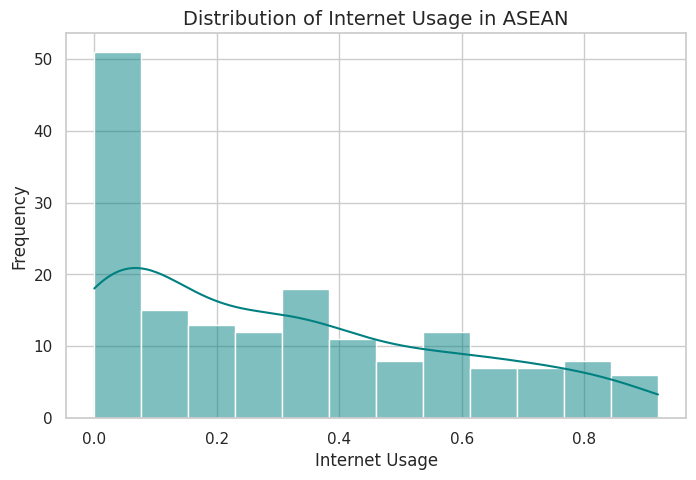

In [ ]:
print("Distribution Analysis")
# Visualize how Internet Usage is distributed across the region
plt.figure(figsize=(8, 5))
sns.histplot(asean_df['Internet_Usage'], bins=12, kde=True, color='teal')
plt.title('Distribution of Internet Usage in ASEAN', fontsize=14)
plt.xlabel('Internet Usage', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

This chart shows that most regions are still struggling to build basic internet infastructure, whereas a small group of countries have a large gap.

Comparative Analysis By Country


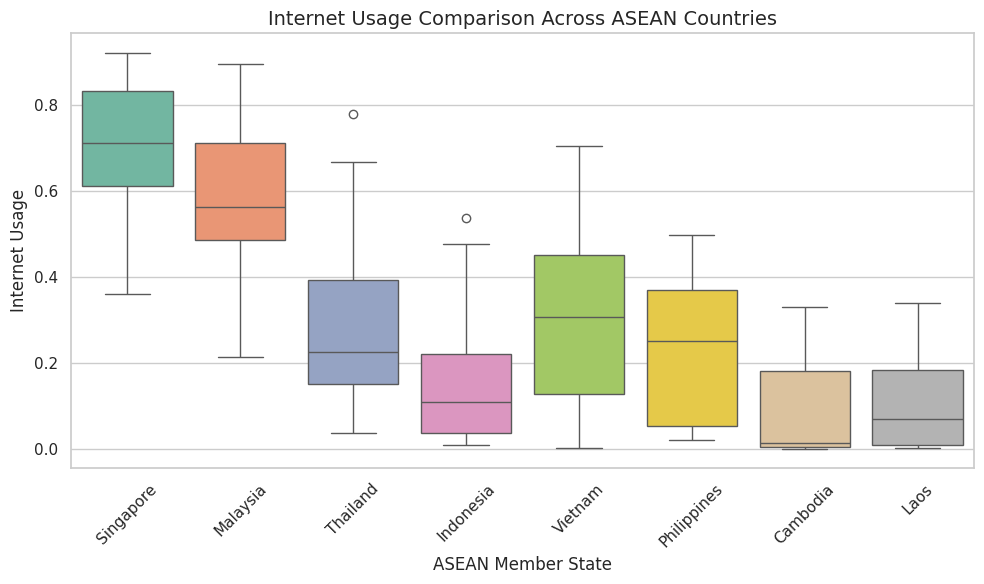

In [ ]:
print("Comparative Analysis By Country")
# A visualization of comparative analysis on the Internet Usage between the different countries
plt.figure(figsize=(10, 6))
sns.boxplot(data=asean_df, x='Country', y='Internet_Usage', hue='Country', palette='Set2', legend=False)
plt.title('Internet Usage Comparison Across ASEAN Countries', fontsize=14)
plt.xlabel('ASEAN Member State', fontsize=12)
plt.ylabel('Internet Usage', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows that Singapore and Malaysi stand out as regional leaders, they maintain a high consistent internet access over the recorded years. The philippines show a stready progress that indicates a rapidly growing connectivity. However, nations like Cambodia, Laos, and Indonesia sit near at the bottom of the chart. This reveals that a large portion of their population still lack basic internet access.